In [266]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import util
from pywaffle import Waffle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from textwrap import wrap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

con = sqlite3.connect('f1_data.db')
driver_colors = {
    # Red Bull Racing (dark blue)
    "Max Verstappen":      "#3671C6",
    "Sergio Perez":        "#134284",

    # Mercedes (teal/silver)
    "Lewis Hamilton":      "#27F4D2",
    "George Russell":      "#12B297",
    "Valtteri Bottas":     "#27F4D2",

    # Ferrari (red)
    "Charles Leclerc":     "#E8002D",
    "Carlos Sainz":        "#8C0721",
    "Oliver Bearman":      "#E8385B",

    # McLaren (papaya orange)
    "Lando Norris":        "#FF8000",
    "Oscar Piastri":       "#FF8000",
    "Daniel Ricciardo":    "#FF8000",

    # Alpine (blue/pink)
    "Fernando Alonso":     "#2293D1",
    "Esteban Ocon":        "#2293D1",
    "Pierre Gasly":        "#2293D1",

    # Aston Martin (green)
    "Lance Stroll":        "#229971",
    "Sebastian Vettel":    "#229971",
    "Nico Hulkenberg":     "#229971",

    # AlphaTauri / RB (navy/white)
    "Yuki Tsunoda":        "#6692FF",
    "Nyck De Vries":       "#6692FF",
    "Liam Lawson":         "#6692FF",

    # Alfa Romeo / Kick Sauber (maroon)
    "Guanyu Zhou":         "#C92D4B",
    "Antonio Giovinazzi":  "#C92D4B",
    "Kimi Räikkönen":      "#C92D4B",
    "Robert Kubica":       "#C92D4B",

    # Haas (white/red)
    "Kevin Magnussen":     "#B6BABD",
    "Mick Schumacher":     "#B6BABD",
    "Nikita Mazepin":      "#B6BABD",

    # Williams (blue)
    "Alexander Albon":     "#64C4FF",
    "Nicholas Latifi":     "#64C4FF",
    "Logan Sargeant":      "#64C4FF",
    "Franco Colapinto":    "#64C4FF",
}

constructor_colors = {
    "Red Bull Racing":  "#3671C6",
    "Mercedes":         "#27F4D2",
    "Ferrari":          "#E8002D",
    "McLaren":          "#FF8000",
    "Alpine":           "#2293D1",
    "Aston Martin":     "#229971",
    "AlphaTauri":       "#6692FF",
    "RB":               "#6692FF",  # AlphaTauri rebranded to RB in 2024
    "Alfa Romeo":       "#C92D4B",
    "Kick Sauber":      "#C92D4B",  # Alfa Romeo rebranded to Kick Sauber in 2024
    "Haas F1 Team":     "#B6BABD",
    "Williams":         "#64C4FF",
}


# F1 data analysis
### In this notebook it is going to be investigated some Formula 1 data from 2021 to 2024. Main idea is to see how does qualifying position depend on driver finish. Then, it is great to see who is making the biggest amount of successfull overtakes per race. Then, to research what was happening in the 2021, when Max and Lewis were both very close to the tittle, but only one got it. And to see, what happened after that year, and how tide was title race

## Reading info from database using SQL query

In [267]:
results = pd.read_sql_query("""
                            SELECT  r.race_Id, r.driver_id,d.full_name, c.name as constructor_name, r.grid_position, r.finish_position, r.points, q.q1,q.q2,q.q3, rc.race_name, rc.season
                            From race_results as r
                            inner join drivers as d on r.driver_id = d.driver_Id
                            inner join constructors as c on r.constructor_id = c.constructor_id
                            inner join qualifying_results as q on r.race_Id = q.race_Id and r.driver_id = q.driver_Id
                            inner join races as rc on r.race_id = rc.race_id
                            """, con)

con.close()

results.head()


,race_id,driver_id,full_name,constructor_name,grid_position,finish_position,points,q1,q2,q3,race_name,season
0,202101,HAM,Lewis Hamilton,Mercedes,2.0,1.0,25.0,0 days 00:01:30.617000,0 days 00:01:30.085000,0 days 00:01:29.385000,Bahrain Grand Prix,2021
1,202101,VER,Max Verstappen,Red Bull Racing,1.0,2.0,18.0,0 days 00:01:30.499000,0 days 00:01:30.318000,0 days 00:01:28.997000,Bahrain Grand Prix,2021
2,202101,BOT,Valtteri Bottas,Mercedes,3.0,3.0,16.0,0 days 00:01:31.200000,0 days 00:01:30.186000,0 days 00:01:29.586000,Bahrain Grand Prix,2021
3,202101,NOR,Lando Norris,McLaren,7.0,4.0,12.0,0 days 00:01:30.902000,0 days 00:01:30.099000,0 days 00:01:29.974000,Bahrain Grand Prix,2021
4,202101,PER,Sergio Perez,Red Bull Racing,0.0,5.0,10.0,0 days 00:01:31.165000,0 days 00:01:30.659000,None,Bahrain Grand Prix,2021


## Handling missing data 

In [268]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   race_id           1659 non-null   int64  
 1   driver_id         1659 non-null   object 
 2   full_name         1659 non-null   object 
 3   constructor_name  1659 non-null   object 
 4   grid_position     1397 non-null   float64
 5   finish_position   1397 non-null   float64
 6   points            1400 non-null   float64
 7   q1                1227 non-null   object 
 8   q2                918 non-null    object 
 9   q3                605 non-null    object 
 10  race_name         1659 non-null   object 
 11  season            1659 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 155.7+ KB


In [269]:
results.describe()

,race_id,grid_position,finish_position,points,season
count,1659.000000,1397.000000,1397.000000,1400.000000,1659.000000
mean,202251.860759,10.200429,10.479599,5.058214,2022.408680
std,108.126514,5.820247,5.757683,7.218533,1.086965
min,202101.000000,0.000000,1.000000,0.000000,2021.000000
25%,202121.000000,5.000000,5.000000,0.000000,2021.000000
50%,202220.000000,10.000000,10.000000,0.250000,2022.000000
75%,202319.000000,15.000000,15.000000,9.000000,2023.000000
max,202417.000000,20.000000,20.000000,26.000000,2024.000000


In [270]:
print(results["finish_position"].isna().sum())

262


In [271]:
print(results["grid_position"].isna().sum())

262


I found **262** null valueі in "finish_position" and in "grid_position" column. I didn't find any information about those races, there are some results in the Internet, but no info in API, I think it is relevant to drop those values, because they will not affect by any way on the future analysis 

In [272]:
results = results.dropna(subset=["finish_position"])

In [273]:
results.isna().sum()

race_id               0
driver_id             0
full_name             0
constructor_name      0
grid_position         0
finish_position       0
points                0
q1                  212
q2                  509
q3                  812
race_name             0
season                0
dtype: int64

Now, we are sure that there are no null value in positions, and points, then we have to handle q1,q2,q3 null values. We will replace null to 0, because null means that drivers didn't get to q2  or q3. Or they didn't start the sessions, and the started from the back. And convert all time to seconds

In [274]:
results["q1_seconds"] = results["q1"].apply(util.to_seconds)
results["q2_seconds"] = results["q2"].apply(util.to_seconds)
results["q3_seconds"] = results["q3"].apply(util.to_seconds)

In [275]:
results.isna().sum()

race_id               0
driver_id             0
full_name             0
constructor_name      0
grid_position         0
finish_position       0
points                0
q1                  212
q2                  509
q3                  812
race_name             0
season                0
q1_seconds            0
q2_seconds            0
q3_seconds            0
dtype: int64

In [276]:
results = results.drop(["q1", "q2", "q3"], axis=1)
results.isna().sum()

race_id             0
driver_id           0
full_name           0
constructor_name    0
grid_position       0
finish_position     0
points              0
race_name           0
season              0
q1_seconds          0
q2_seconds          0
q3_seconds          0
dtype: int64

We handled missing data, we can move on to EDA

## EDA

First important thing I wanted to see is correlation between quali results and race results

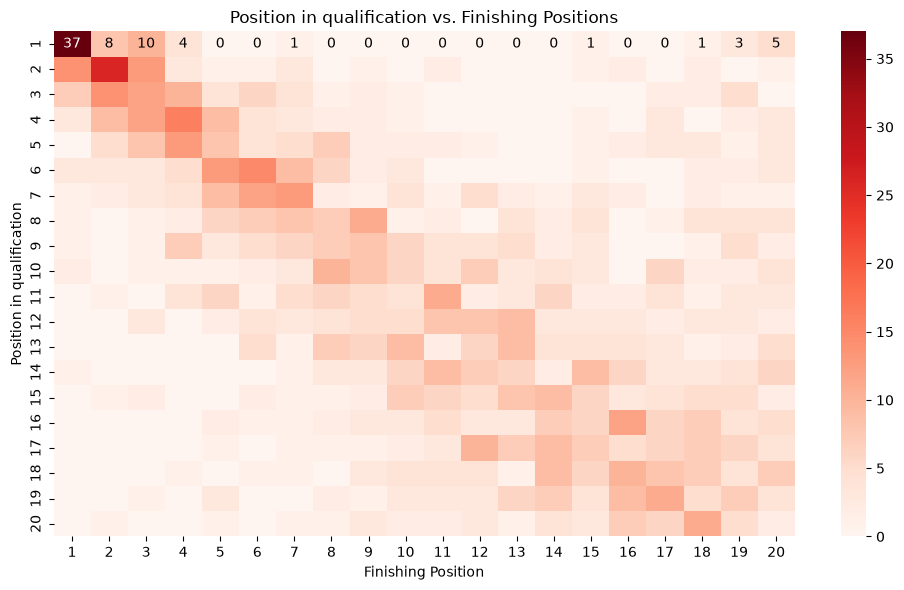

In [277]:
plot_data = results[["grid_position", "finish_position"]].copy()
plot_data["grid_position"] = plot_data["grid_position"].astype(int)
plot_data["finish_position"] = plot_data["finish_position"].astype(int)

heatmap_data = pd.crosstab(
    plot_data["grid_position"],
    plot_data["finish_position"]
).reindex(index=range(1, 21), columns=range(1, 21), fill_value=0)

plt.figure(figsize=(10, 6))
ax =sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=False,
    fmt="d",
    cbar=True,
    linewidths= 0
)

for col, value in enumerate(heatmap_data.iloc[0]):
    ax.text(
        col + 0.5,
        0.5,
        int(value),
        ha="center",
        va="center",
        color="white" if value > heatmap_data.values.max() / 2 else "black"
    )

plt.title("Position in qualification vs. Finishing Positions")
plt.xlabel("Finishing Position")
plt.ylabel("Position in qualification") 
plt.tight_layout()
plt.show()


It is can be seen that position in qualification very often determines your finishing position. Sometimes it is as important as the race

*The next very interesting point to look at is which of the drivers has the highest realisation of its grid position* 

In [278]:
results_analysis = results.copy()
results_analysis["avg_gained_positions"] =results_analysis.groupby("driver_id")["grid_position"].transform(lambda x: (x - results_analysis["finish_position"]).mean())

avg_gained_postions_rank = results_analysis[["full_name", "avg_gained_positions"]].drop_duplicates().sort_values(by="avg_gained_positions", ascending=False).head(10)
avg_gained_postions_rank

,full_name,avg_gained_positions
1630,Franco Colapinto,6.000000
1346,Oliver Bearman,4.000000
254,Robert Kubica,2.000000
1132,Liam Lawson,1.600000
891,Logan Sargeant,1.307692
9,Lance Stroll,1.173913
19,Nikita Mazepin,0.666667
748,Nyck De Vries,0.545455
1,Max Verstappen,0.528571
470,Guanyu Zhou,0.416667


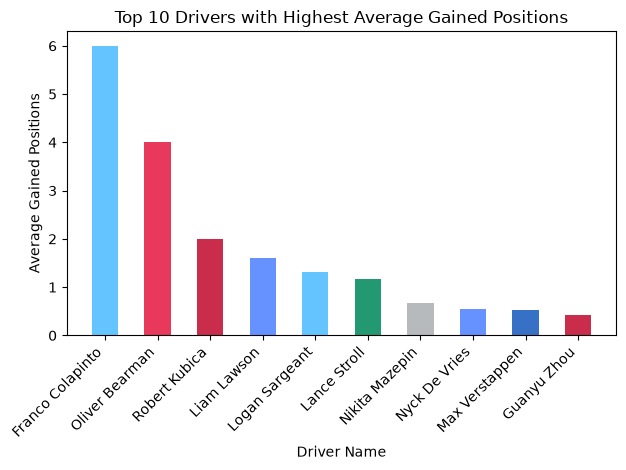

In [279]:
plt.bar(avg_gained_postions_rank["full_name"], avg_gained_postions_rank["avg_gained_positions"], width=0.5, color = [driver_colors.get(name, "#333333") for name in avg_gained_postions_rank["full_name"]])
plt.title("Top 10 Drivers with Highest Average Gained Positions")
plt.xlabel("Driver Name")
plt.ylabel("Average Gained Positions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Next we will look at the number of gained points by drivers and then the teams

In [280]:
results_analysis["sum_of_points"] = results_analysis.groupby("driver_id")["points"].transform("sum")
top_gained_points = results_analysis[["full_name","sum_of_points"]].drop_duplicates().sort_values(by="sum_of_points", ascending=False).head(10)
top_gained_points

,full_name,sum_of_points
1,Max Verstappen,1439.5
0,Lewis Hamilton,880.5
4,Sergio Perez,774.0
5,Charles Leclerc,659.0
7,Carlos Sainz,582.5
3,Lando Norris,549.0
13,George Russell,455.0
18,Fernando Alonso,389.0
2,Valtteri Bottas,268.0
12,Esteban Ocon,203.0


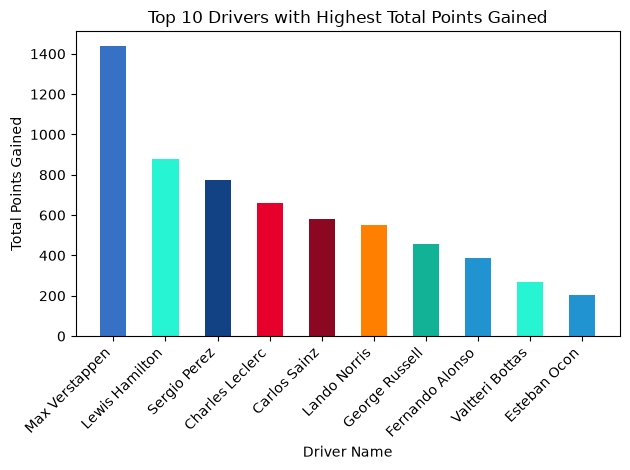

In [281]:
plt.bar(top_gained_points["full_name"], top_gained_points["sum_of_points"], width=0.5,color = [driver_colors.get(name, "#333333") for name in top_gained_points["full_name"]])
plt.title("Top 10 Drivers with Highest Total Points Gained")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's see how much points did Max Verstappen take from all of the points for these years

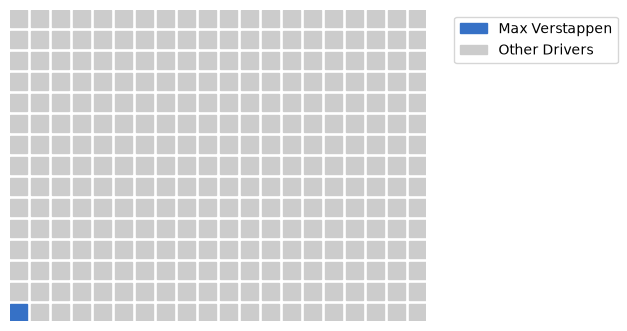

In [282]:
max_points = results_analysis["sum_of_points"].where(results_analysis["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis["sum_of_points"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
    colors=[driver_colors.get("Max Verstappen", "#333333"), "#CCCCCC"],
)
plt.show()

In [283]:
percentage_max = (max_points / results_analysis["sum_of_points"].sum()) * 100
print(percentage_max)

0.30013875814070345


Although, Max has the highest number of points, it is still 0.3% of all points gained from 2021 to 2024

In [284]:
results_analysis["sum_of_points_constructor"] = results_analysis.groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor = results_analysis[["constructor_name","sum_of_points_constructor"]].drop_duplicates().sort_values(by="sum_of_points_constructor", ascending=False).head(10)
top_gained_points_by_constructor

,constructor_name,sum_of_points_constructor
1,Red Bull Racing,2213.5
0,Mercedes,1538.5
5,Ferrari,1247.5
3,McLaren,859.0
9,Aston Martin,433.0
12,Alpine,419.0
8,AlphaTauri,189.0
10,Alfa Romeo,73.0
13,Williams,59.0
15,Haas F1 Team,43.0


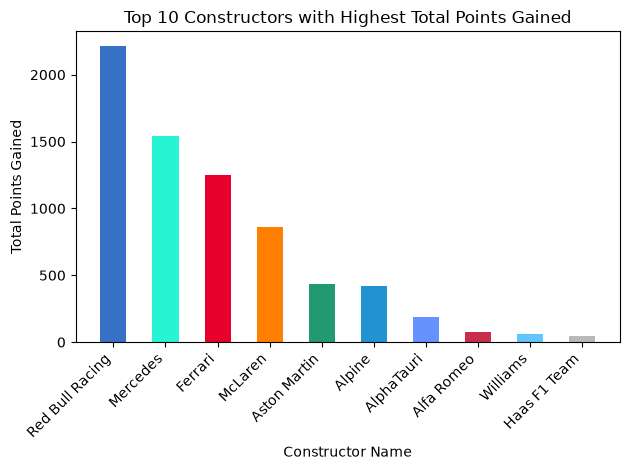

In [285]:
plt.bar(top_gained_points_by_constructor["constructor_name"], top_gained_points_by_constructor["sum_of_points_constructor"],width=0.5,color = [constructor_colors.get(name, "#333333") for name in top_gained_points_by_constructor["constructor_name"]])
plt.title("Top 10 Constructors with Highest Total Points Gained")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We can see that if we would compare Max Verstappen to the whole teams(excluding his team Red Bull Racing), Max would be on the second place with 99 points difference with Mercedes team. 

Lets visualize it

In [286]:
results_analysis_1 = results_analysis.copy()
max_points_df = pd.DataFrame({"constructor_name": ["Max Verstappen"], "sum_of_points_constructor": max_points})
results_analysis_1 = pd.concat([results_analysis_1,max_points_df], ignore_index=True)
results_analysis_1 = results_analysis_1.sort_values(by="sum_of_points_constructor", ascending=False).drop_duplicates(subset=["constructor_name"], keep="first")
results_analysis_1 = results_analysis_1[["constructor_name","sum_of_points_constructor"]].head(10)
results_analysis_1

,constructor_name,sum_of_points_constructor
824,Red Bull Racing,2213.5
402,Mercedes,1538.5
1397,Max Verstappen,1439.5
576,Ferrari,1247.5
260,McLaren,859.0
667,Aston Martin,433.0
1085,Alpine,419.0
313,AlphaTauri,189.0
1115,Alfa Romeo,73.0
435,Williams,59.0


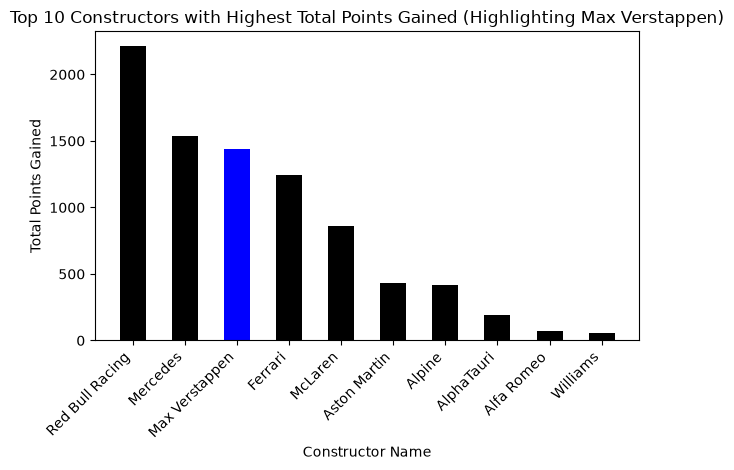

In [287]:
plt.bar(results_analysis_1["constructor_name"], results_analysis_1["sum_of_points_constructor"], width=0.5, color=['blue' if name == "Max Verstappen" else "#000000" for name in results_analysis_1["constructor_name"]] )
plt.title("Top 10 Constructors with Highest Total Points Gained (Highlighting Max Verstappen)")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, we will see what the difference is from 2022-2024, because 2021 was a year where the Max's domination has not started yet.

In [288]:
results_analysis["sum_of_points_after_2021"] = results_analysis.where(lambda x: results_analysis["season"] > 2021).groupby("driver_id")["points"].transform("sum")
results_analysis_after_2021 = results_analysis[["full_name","sum_of_points_after_2021"]].drop_duplicates().sort_values(by="sum_of_points_after_2021", ascending=False).head(10)
results_analysis_after_2021

,full_name,sum_of_points_after_2021
460,Max Verstappen,1051.0
463,Sergio Perez,584.0
461,Charles Leclerc,500.0
469,Lewis Hamilton,495.0
464,George Russell,439.0
462,Carlos Sainz,419.0
466,Lando Norris,389.0
475,Fernando Alonso,308.0
899,Oscar Piastri,162.0
465,Esteban Ocon,129.0


We can see that point difference is huge

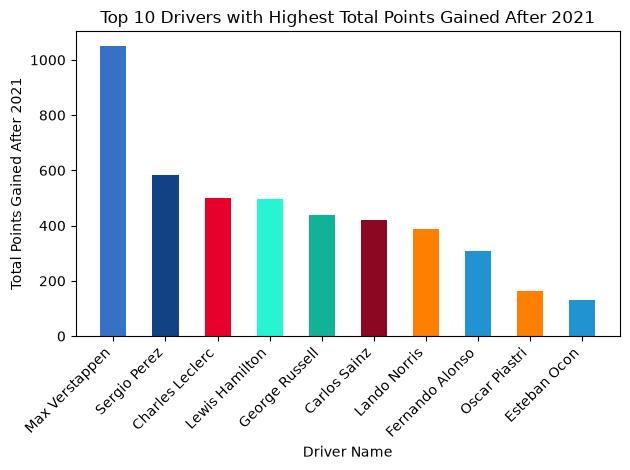

In [289]:
plt.bar(results_analysis_after_2021["full_name"], results_analysis_after_2021["sum_of_points_after_2021"], width=0.5, color = [driver_colors.get(name, "#333333") for name in results_analysis_after_2021["full_name"]])
plt.title("Top 10 Drivers with Highest Total Points Gained After 2021")
plt.xlabel("Driver Name")
plt.ylabel("Total Points Gained After 2021")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now, lets see the same graph of waffle

Out of all gained points Max took: 23.48078641644325%


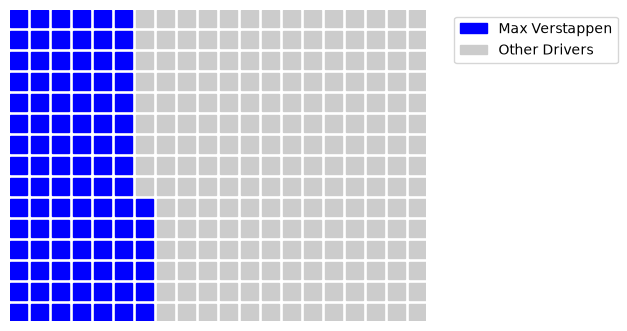

In [290]:
max_points_after_2021 = results_analysis_after_2021["sum_of_points_after_2021"].where(results_analysis_after_2021["full_name"]=="Max Verstappen").dropna().values[0]
data={
    "Max Verstappen": max_points,
    "Other Drivers": results_analysis_after_2021["sum_of_points_after_2021"].sum() - max_points
}
plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=20,
    values=data,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
    colors=["blue","#CCCCCC"]
)
percentage_max = (max_points_after_2021 / results_analysis_after_2021["sum_of_points_after_2021"].sum()) * 100
print(f"Out of all gained points Max took: {percentage_max}%")
plt.show()

Now, we can see how the domination changed everything. Lets compare to the constructors again

In [291]:
results_analysis["sum_of_points_constructors_after_2021"] = results_analysis.where(lambda x: results_analysis["season"] > 2021).groupby("constructor_name")["points"].transform("sum")
top_gained_points_by_constructor_after_2021 = results_analysis[["constructor_name","sum_of_points_constructors_after_2021"]].drop_duplicates().sort_values(by="sum_of_points_constructors_after_2021", ascending=False).head(10)
top_gained_points_by_constructor_after_2021

,constructor_name,sum_of_points_constructors_after_2021
460,Red Bull Racing,1635.0
464,Mercedes,934.0
461,Ferrari,925.0
466,McLaren,585.0
471,Aston Martin,356.0
465,Alpine,264.0
470,Alfa Romeo,60.0
467,AlphaTauri,47.0
468,Haas F1 Team,43.0
473,Williams,36.0


After 2021 Max Verstappen gained more points than all teams(excluding his team), he can be compared only with the teams.

In [292]:
max_points_after_2021_df = pd.DataFrame({"constructor_name": ["Max Verstappen"], "sum_of_points_constructors_after_2021": max_points_after_2021})
top_gained_points_by_constructor_after_2021 = pd.concat([top_gained_points_by_constructor_after_2021, max_points_after_2021_df])
top_gained_points_by_constructor_after_2021 = top_gained_points_by_constructor_after_2021.sort_values(by="sum_of_points_constructors_after_2021",ascending=False)
top_gained_points_by_constructor_after_2021 = top_gained_points_by_constructor_after_2021.drop(top_gained_points_by_constructor_after_2021[top_gained_points_by_constructor_after_2021['constructor_name'] == "Red Bull Racing"].index)
top_gained_points_by_constructor_after_2021.head(10)

,constructor_name,sum_of_points_constructors_after_2021
0,Max Verstappen,1051.0
464,Mercedes,934.0
461,Ferrari,925.0
466,McLaren,585.0
471,Aston Martin,356.0
465,Alpine,264.0
470,Alfa Romeo,60.0
467,AlphaTauri,47.0
468,Haas F1 Team,43.0
473,Williams,36.0


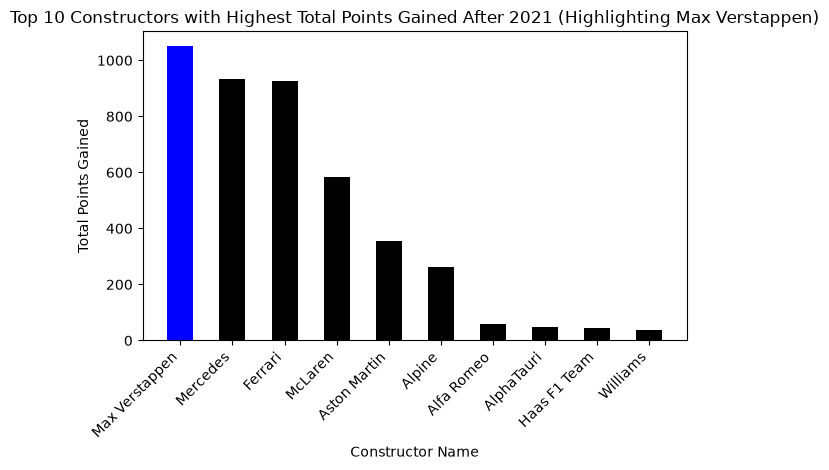

In [293]:
plt.bar(top_gained_points_by_constructor_after_2021["constructor_name"], top_gained_points_by_constructor_after_2021["sum_of_points_constructors_after_2021"], width=0.5, color=['blue' if name == "Max Verstappen" else '#000000' for name in top_gained_points_by_constructor_after_2021["constructor_name"]])
plt.title("Top 10 Constructors with Highest Total Points Gained After 2021 (Highlighting Max Verstappen)")
plt.xlabel("Constructor Name")
plt.ylabel("Total Points Gained")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's Investigate how the situation in the driver standings looked in the most competing year - 2021

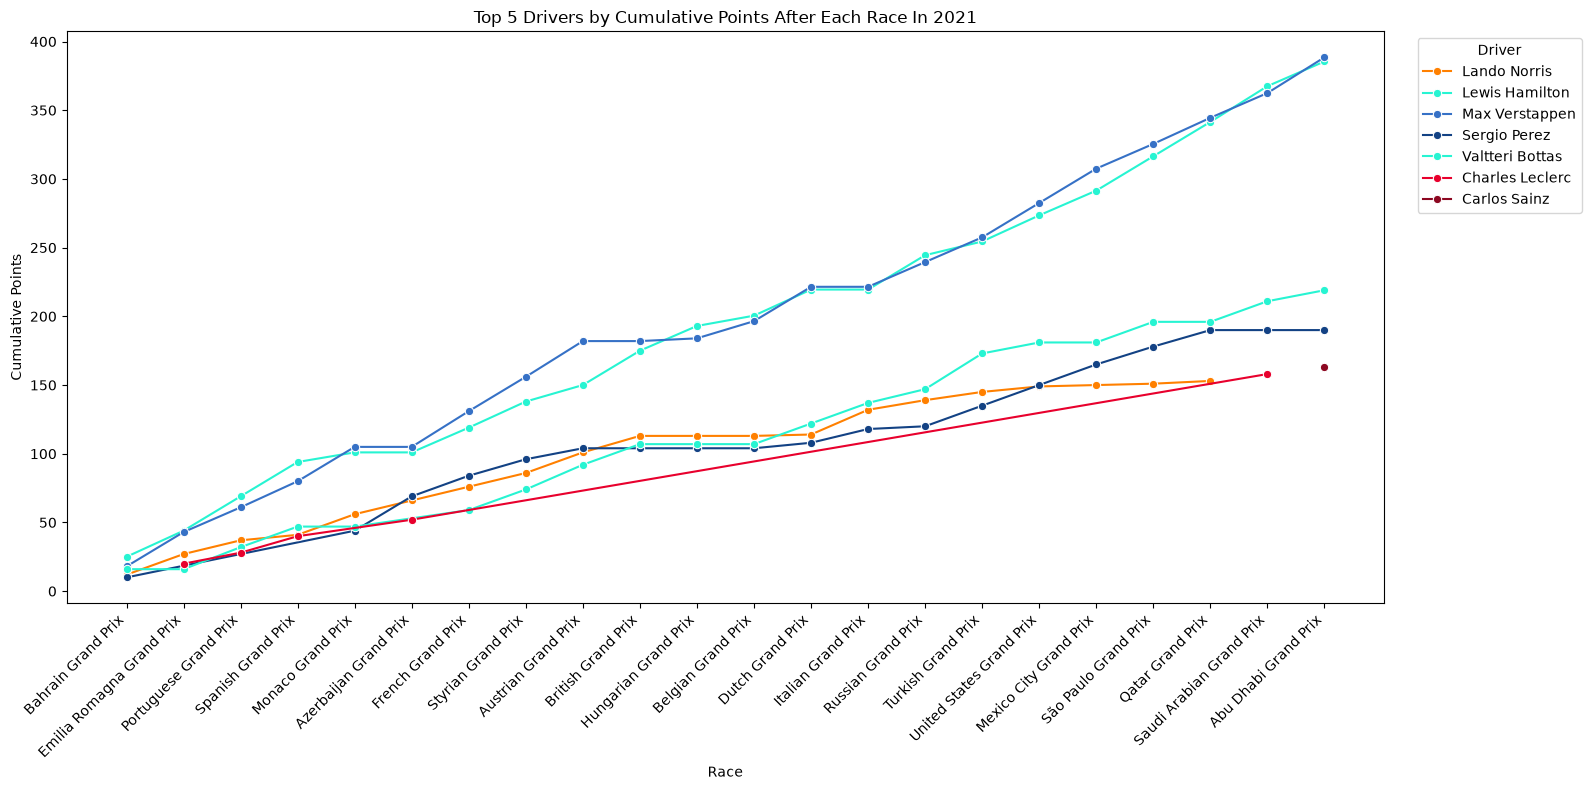

In [294]:
# Build cumulative points by race
# used copilot for this section



standings = results_analysis[results_analysis["season"] == 2021].copy()

# Some race_result tables may contain multiple rows per driver/race in edge cases,
# so aggregate safely to one row per driver per race
standings = (
    standings
    .groupby(["race_id", "season", "race_name", "full_name"], as_index=False)["points"]
    .sum()
)

# Ensure races are in chronological order
race_order = (
    standings[["race_id", "season", "race_name"]]
    .drop_duplicates()
    .sort_values(["season", "race_id"])
)
race_order["race_round"] = np.arange(1, len(race_order) + 1)

standings = standings.merge(race_order, on=["race_id", "season", "race_name"], how="left")
standings = standings.sort_values(["race_round", "full_name"])

# Cumulative points per driver after each race
standings["cumulative_points"] = standings.groupby("full_name")["points"].cumsum()

# Driver rank after each race
standings["rank_after_race"] = (
    standings.groupby("race_round")["cumulative_points"]
    .rank(method="dense", ascending=False)
)

top5_each_race = standings[standings["rank_after_race"] <= 5].copy()

# Keep x-axis readable
top5_each_race["race_label"] = (
    top5_each_race["season"].astype(str) + " - " + top5_each_race["race_name"]
)

plt.figure(figsize=(16, 8))
sns.lineplot(
    data=top5_each_race,
    x="race_round",
    y="cumulative_points",
    hue="full_name",
    marker="o",
    palette= driver_colors
)

# Show fewer x ticks for readability
tick_step = max(1, len(race_order) // 12)
tick_positions = race_order["race_round"].iloc[::tick_step]
tick_labels = (
    race_order["race_name"]
).iloc[::tick_step]

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.title("Top 5 Drivers by Cumulative Points After Each Race In 2021")
plt.xlabel("Race")
plt.ylabel("Cumulative Points")
plt.legend(title="Driver", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Let's compare drivers with the violin plot of gained position.**

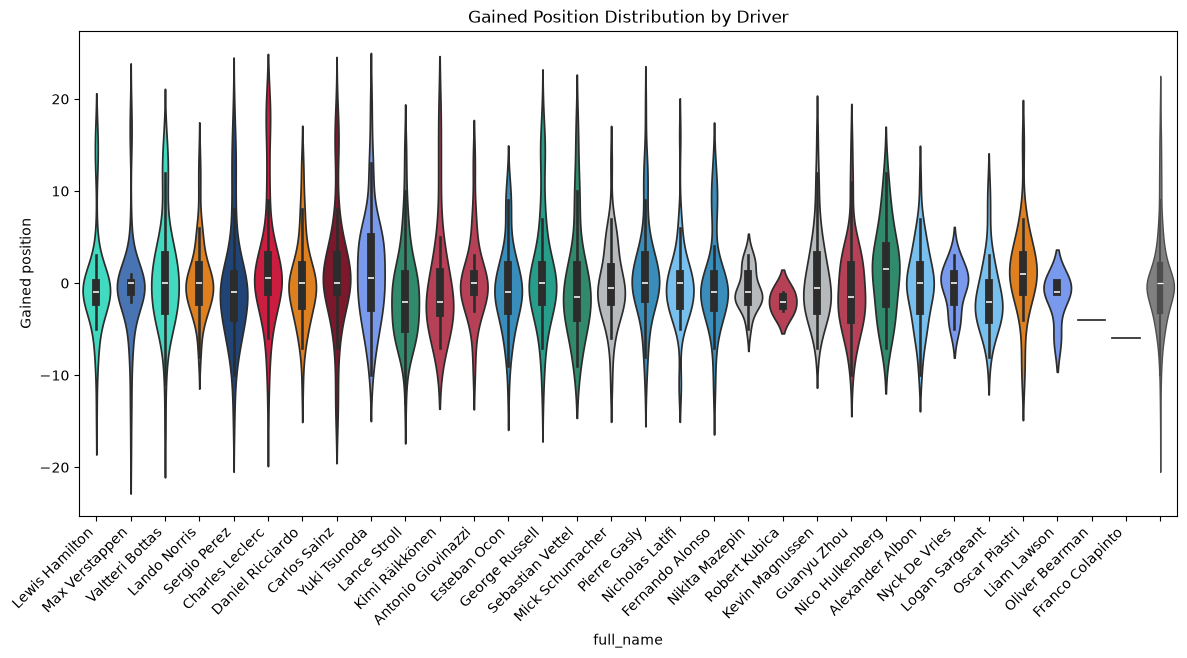

In [295]:
results_analysis["gained_position"] = results_analysis["finish_position"] - results_analysis["grid_position"]


plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=results_analysis['full_name'], y=results_analysis['gained_position'], palette=driver_colors, hue=results_analysis["full_name"])
sns.violinplot(y=results_analysis['gained_position'], color='gray', linewidth=1.0)
plt.title('Gained Position Distribution by Driver')
plt.ylabel('Gained position')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


**Lets see the violin plot of finishing and qulifying**

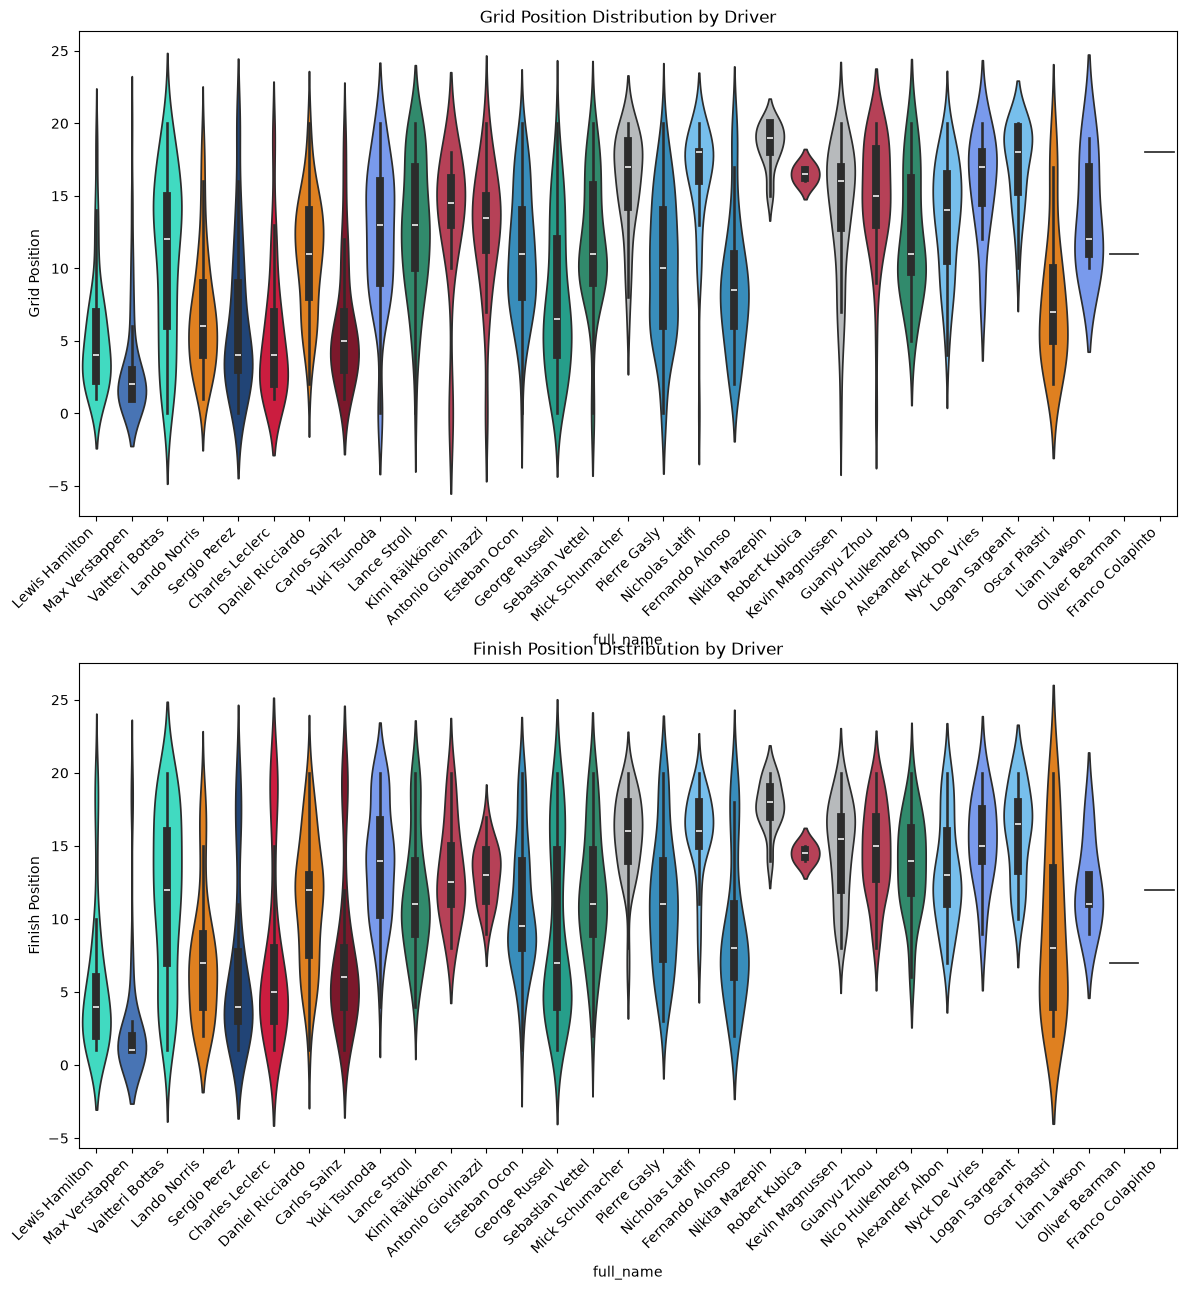

In [296]:
plt.figure(figsize=(12, 18))
plt.subplot(3, 1, 1)
sns.violinplot(x=results_analysis["full_name"], y=results_analysis["grid_position"], palette=driver_colors, hue=results_analysis["full_name"])
plt.title("Grid Position Distribution by Driver")
plt.ylabel("Grid Position")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.subplot(3, 1, 2)
sns.violinplot(x=results_analysis["full_name"], y=results_analysis["finish_position"], palette=driver_colors, hue=results_analysis["full_name"])
plt.title("Finish Position Distribution by Driver")
plt.ylabel("Finish Position")
plt.xticks(rotation=45, ha='right')


plt.show()

For the machine learning model it is important to know the correlation between column, so lets do a heatmap graph. And lets add some info about circuits, for some drivers circuit may be very important.

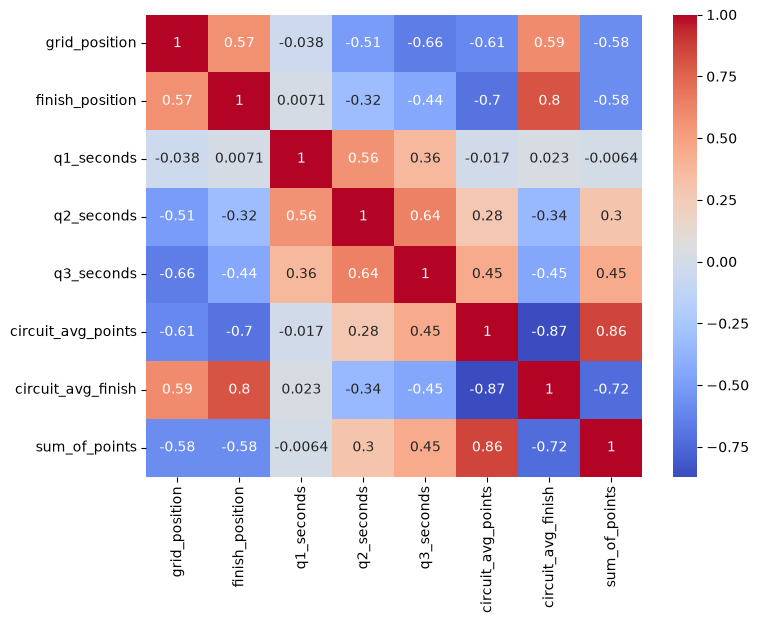

In [297]:
circuit_avg_points = results_analysis.groupby(["race_name", "full_name"])["points"].transform("mean")
results_analysis["circuit_avg_points"] = circuit_avg_points
circuit_avg_finish = results_analysis.groupby(["race_name", "full_name"])["finish_position"].transform("mean")
results_analysis["circuit_avg_finish"] = circuit_avg_finish




corr_df = results_analysis[["grid_position", "finish_position", "q1_seconds", "q2_seconds", "q3_seconds","circuit_avg_points", "circuit_avg_finish","sum_of_points"]]
corr = corr_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

We found a big correlation between a track and driver performance, but the problem that it may be caused by the low amount of races, and we have to be careful with this investigation. Lets see the correlation without track data 

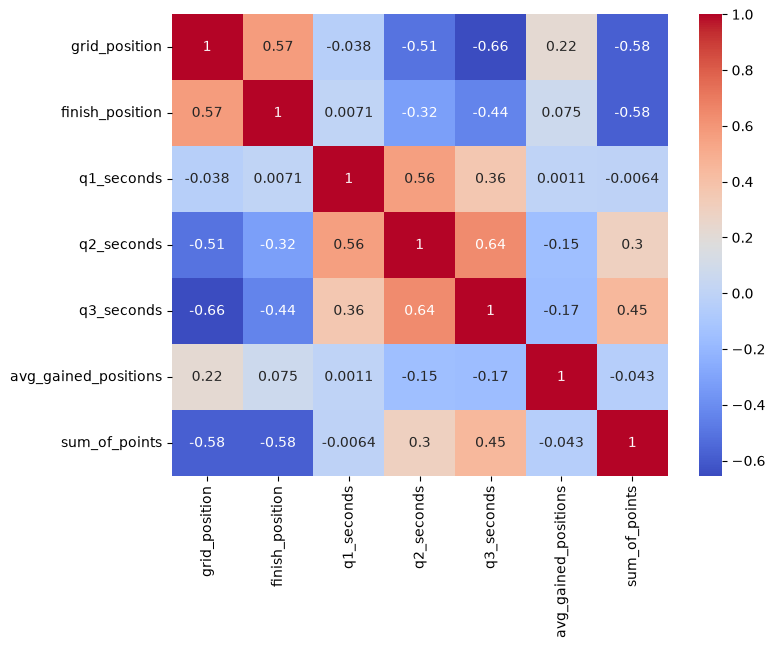

In [298]:
corr_df = results_analysis[["grid_position", "finish_position", "q1_seconds", "q2_seconds", "q3_seconds", "avg_gained_positions","sum_of_points"]]
corr = corr_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Key Insights from the analysis
- Position in qualifying almost everytime determines the winner. In 55 times out of 70 qulifying winner took podium
- *Franco Colapinto* is the driver who does the biggest amount of successful overtakes
-  **Max Verstappen** as the champion was flawless during these years, his success could be compared with whole constructors. After becoming a champion he gained almost 1/4 of all points.
- Red Bull Racing was the most successfull team throught all the researched time.
- Grid position correlates with finish position, with gained position
- Unsurprisingly, circuit has a big correlation with finish position, but it it dangerous to use for predictions

# Machine Learning
##### Moving on to the final part of the project - making a predictive model for 2024 championship using previous data

Lets drop column that we will not use for our future model

In [299]:
results_analysis_model = results_analysis.drop(["sum_of_points_after_2021", "sum_of_points_constructors_after_2021"], axis=1)
results_analysis_model = results_analysis_model.where(results_analysis_model["season"] < 2024)
results_analysis_model = results_analysis_model.dropna(subset=["grid_position", "finish_position", "q2_seconds", "q3_seconds", "circuit_avg_finish", "circuit_avg_points", "sum_of_points"])
results_analysis_model

,race_id,driver_id,full_name,constructor_name,grid_position,finish_position,points,race_name,season,q1_seconds,q2_seconds,q3_seconds,avg_gained_positions,sum_of_points,sum_of_points_constructor,gained_position,circuit_avg_points,circuit_avg_finish
0,202101.0,HAM,Lewis Hamilton,Mercedes,2.0,1.0,25.0,Bahrain Grand Prix,2021.0,90.617,90.085,89.385,0.128571,880.5,1538.5,-1.0,17.500000,3.000000
1,202101.0,VER,Max Verstappen,Red Bull Racing,1.0,2.0,18.0,Bahrain Grand Prix,2021.0,90.499,90.318,88.997,0.528571,1439.5,2213.5,1.0,21.500000,1.500000
2,202101.0,BOT,Valtteri Bottas,Mercedes,3.0,3.0,16.0,Bahrain Grand Prix,2021.0,91.200,90.186,89.586,-0.942857,268.0,1538.5,0.0,10.000000,5.500000
3,202101.0,NOR,Lando Norris,McLaren,7.0,4.0,12.0,Bahrain Grand Prix,2021.0,90.902,90.099,89.974,-0.385714,549.0,859.0,-3.0,6.000000,10.500000
4,202101.0,PER,Sergio Perez,Red Bull Racing,0.0,5.0,10.0,Bahrain Grand Prix,2021.0,91.165,90.659,0.000,0.185714,774.0,2213.5,5.0,14.000000,3.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,202322.0,SAR,Logan Sargeant,Williams,20.0,16.0,0.0,Abu Dhabi Grand Prix,2023.0,0.000,0.000,0.000,1.307692,1.0,59.0,-4.0,0.000000,16.000000
1316,202322.0,ZHO,Guanyu Zhou,Alfa Romeo,19.0,17.0,0.0,Abu Dhabi Grand Prix,2023.0,0.000,0.000,0.000,0.416667,11.0,73.0,-2.0,0.000000,14.500000
1317,202322.0,SAI,Carlos Sainz,Ferrari,16.0,18.0,0.0,Abu Dhabi Grand Prix,2023.0,0.000,0.000,0.000,-1.159420,582.5,1247.5,2.0,9.000000,8.333333
1318,202322.0,BOT,Valtteri Bottas,Alfa Romeo,18.0,19.0,0.0,Abu Dhabi Grand Prix,2023.0,0.000,0.000,0.000,-0.942857,268.0,73.0,1.0,2.666667,13.333333


In [300]:
train_x, test_x, train_y, test_y = train_test_split(results_analysis_model[["grid_position", "q2_seconds", "q3_seconds","circuit_avg_finish","circuit_avg_points"]], 
                                                    results_analysis_model["finish_position"], test_size=0.2, random_state=42)

Lets try to evaluate different model, then choose the best out of them, and make final predictions on 2024

In [301]:

model_LR = LinearRegression()
model_LR.fit(train_x, train_y)
model_LR_predictions = model_LR.predict(test_x)
model_LR_mae = mean_absolute_error(test_y, model_LR_predictions)
model_LR_r2 = r2_score(test_y, model_LR_predictions)
model_LR_cv_scores = cross_val_score(model_LR, results_analysis[["grid_position", "q2_seconds", "q3_seconds", "avg_gained_positions","circuit_avg_finish"]], results_analysis["finish_position"], cv=5)

print(f"Linear Regression Cross-Validation Scores: {model_LR_cv_scores}")
print(f"Linear Regression MAE: {model_LR_mae}")
print(f"Linear Regression R^2: {model_LR_r2}")


Linear Regression Cross-Validation Scores: [0.60240787 0.69283779 0.63876064 0.66621908 0.68365409]
Linear Regression MAE: 2.262742356714008
Linear Regression R^2: 0.6787363636379775


In [302]:
model_Ridge = Ridge(alpha=1.0)
model_Ridge.fit(train_x, train_y)
model_Ridge_predictions = model_Ridge.predict(test_x)
model_Ridge_mae = mean_absolute_error(test_y, model_Ridge_predictions)
model_Ridge_r2 = r2_score(test_y, model_Ridge_predictions)
model_Ridge_cv_scores = cross_val_score(model_Ridge, results_analysis[["grid_position", "q2_seconds", "q3_seconds", "avg_gained_positions","circuit_avg_finish"]], results_analysis["finish_position"], cv=5)

print(f"Ridge Regression Cross-Validation Scores: {model_Ridge_cv_scores}")
print(f"Ridge Regression MAE: {model_Ridge_mae}")
print(f"Ridge Regression R^2: {model_Ridge_r2}")

Ridge Regression Cross-Validation Scores: [0.60241794 0.69284212 0.63875691 0.666218   0.68365005]
Ridge Regression MAE: 2.2626758375766225
Ridge Regression R^2: 0.6787446054938893


In [303]:
model_forest = RandomForestRegressor(n_estimators=100, random_state=42)
model_forest.fit(train_x, train_y)
model_forest_predictions = model_forest.predict(test_x)
model_forest_mae = mean_absolute_error(test_y, model_forest_predictions)
model_forest_r2 = r2_score(test_y, model_forest_predictions)
model_forest_cv_scores = cross_val_score(model_forest, results_analysis[["grid_position", "q2_seconds", "q3_seconds", "avg_gained_positions","circuit_avg_finish"]], results_analysis["finish_position"], cv=5)

print(f"Random Forest Cross-Validation Scores: {model_forest_cv_scores}")
print(f"Random Forest MAE: {model_forest_mae}")
print(f"Random Forest R^2: {model_forest_r2}")

Random Forest Cross-Validation Scores: [0.46903767 0.60616929 0.50788079 0.54332586 0.56647848]
Random Forest MAE: 2.384785566836162
Random Forest R^2: 0.5684516920177523


In [304]:
model_boost = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_boost.fit(train_x, train_y)
model_boost_predictions = model_boost.predict(test_x)
model_boost_mae = mean_absolute_error(test_y, model_boost_predictions)
model_boost_r2 = r2_score(test_y, model_boost_predictions)
model_boost_cv_scores = cross_val_score(model_boost, results_analysis[["grid_position", "q2_seconds", "q3_seconds", "avg_gained_positions","circuit_avg_finish"]], results_analysis["finish_position"], cv=5)

print(f"Gradient Boosting Cross-Validation Scores: {model_boost_cv_scores}")
print(f"Gradient Boosting MAE: {model_boost_mae}")
print(f"Gradient Boosting R^2: {model_boost_r2}")

Gradient Boosting Cross-Validation Scores: [0.54326783 0.65055586 0.58986554 0.61022602 0.65652015]
Gradient Boosting MAE: 2.338929743179227
Gradient Boosting R^2: 0.6176367559505782


### Comparing models, **Linear and Ridge Regression** outperformed Random Forest and Gradient Boost, achieving a test $R^2$ of **~0.69** and an MSE of **~2.24** (RMSE $\approx 1.50$ positions). Because qualifying position directly anchors race outcome in a monotonic manner, linear models capture this dynamic without overfitting. Random Forest exhibited lower cross-validation stability ($R^2 \approx 0.56$), showing that simpler, regularized linear models are better suited for this feature set.

# Final prediction of 2024
#### Lets predict 2024 year with Linear Model and with the best parametres searched for it

In [305]:
search_params = GridSearchCV(
    estimator=LinearRegression(),
    param_grid={
        'fit_intercept': [True, False],
        'positive': [True, False],
        'copy_X': [True, False],
        'tol': [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
    },
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
search_params.fit(train_x, train_y)
print(f"Best parameters for Linear Regression: {search_params.best_params_}")

Best parameters for Linear Regression: {'copy_X': True, 'fit_intercept': False, 'positive': False, 'tol': 0.0001}


In [306]:
final_model = LinearRegression(**search_params.best_params_)
X = results_analysis_model[["grid_position", "q2_seconds", "q3_seconds","circuit_avg_finish","circuit_avg_points"]]
y = results_analysis_model["finish_position"]
final_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",0.0001
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.09, 0. ,-0.01, 0.92, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['grid_position','q2_seconds','q3_seconds','circuit_avg_finish', 'circuit_avg_points']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float,0
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [307]:
results_analysis_predict = results_analysis.drop(["sum_of_points_after_2021", "sum_of_points_constructors_after_2021"], axis=1)
results_analysis_predict = results_analysis_predict.where(results_analysis_predict["season"] == 2024)
results_analysis_predict = results_analysis_predict.dropna(subset=["grid_position", "finish_position", "q2_seconds", "q3_seconds", "circuit_avg_finish", "circuit_avg_points"])
x_predict = results_analysis_predict[["grid_position", "q2_seconds", "q3_seconds","circuit_avg_finish","circuit_avg_points"]]
y_predict = results_analysis_predict["finish_position"]
x_predict

,grid_position,q2_seconds,q3_seconds,circuit_avg_finish,circuit_avg_points
1340,1.0,0.0,0.0,1.50,21.750000
1341,3.0,0.0,0.0,6.00,13.750000
1342,2.0,0.0,0.0,4.75,11.750000
1343,5.0,0.0,0.0,9.50,6.000000
1344,4.0,0.0,0.0,9.25,6.250000
...,...,...,...,...,...
1634,19.0,0.0,0.0,10.50,4.000000
1635,10.0,0.0,0.0,17.00,0.000000
1636,20.0,0.0,0.0,14.00,0.333333
1637,17.0,0.0,0.0,15.00,1.500000


In [308]:
final_model.predict(x_predict)
df = pd.DataFrame({
    "Driver": results_analysis_predict["full_name"],
    "Predicted Finish Position": final_model.predict(x_predict),
    "Actual Finish Position": y_predict
})
print(df)

               Driver  Predicted Finish Position  Actual Finish Position
1340   Max Verstappen                   2.230427                     1.0
1341     Sergio Perez                   6.272142                     2.0
1342  Charles Leclerc                   4.960958                     3.0
1343    Oscar Piastri                   9.403455                     4.0
1344  Fernando Alonso                   9.089947                     5.0
...               ...                        ...                     ...
1634  Valtteri Bottas                  11.547099                    16.0
1635  Nico Hulkenberg                  16.549736                    17.0
1636      Guanyu Zhou                  14.728506                    18.0
1637     Lance Stroll                  15.411007                    19.0
1638     Yuki Tsunoda                  18.483146                    20.0

[140 rows x 3 columns]


Below is the actual vs predicted finish-position table for every driver in every race.

In [309]:
predictions_table = results_analysis_predict[["season", "race_name", "full_name", "constructor_name", "grid_position"]].reset_index(drop=True).copy()
predictions_table["Actual Finish Position"] = y_predict.reset_index(drop=True).round(0).astype(int).to_numpy()
predictions_table["Predicted Finish Position"] = final_model.predict(x_predict).round(2)
predictions_table["Prediction Error"] = predictions_table["Predicted Finish Position"] - predictions_table["Actual Finish Position"]
predictions_table = predictions_table.sort_values(
    ["season", "race_name", "Actual Finish Position", "full_name"]
).reset_index(drop=True)
predictions_table.to_excel("predictions_table.xlsx", index=False)
predictions_table.to_csv("predictions_table.csv", index=False)
predictions_table

,season,race_name,full_name,constructor_name,grid_position,Actual Finish Position,Predicted Finish Position,Prediction Error
0,2024.0,Belgian Grand Prix,Lewis Hamilton,Mercedes,3.0,1,7.11,6.11
1,2024.0,Belgian Grand Prix,Oscar Piastri,McLaren,5.0,2,10.89,8.89
2,2024.0,Belgian Grand Prix,Charles Leclerc,Ferrari,1.0,3,5.04,2.04
3,2024.0,Belgian Grand Prix,Max Verstappen,Red Bull Racing,11.0,4,3.28,-0.72
4,2024.0,Belgian Grand Prix,Lando Norris,McLaren,4.0,5,9.24,4.24
...,...,...,...,...,...,...,...,...
135,2024.0,Saudi Arabian Grand Prix,Daniel Ricciardo,RB,14.0,16,13.05,-2.95
136,2024.0,Saudi Arabian Grand Prix,Valtteri Bottas,Kick Sauber,16.0,17,13.79,-3.21
137,2024.0,Saudi Arabian Grand Prix,Guanyu Zhou,Kick Sauber,20.0,18,14.72,-3.28
138,2024.0,Saudi Arabian Grand Prix,Lance Stroll,Aston Martin,10.0,19,15.40,-3.60


We can see that not every predict was true, lets evaluate our results. 

In [310]:
model_mae = mean_absolute_error(predictions_table["Actual Finish Position"], predictions_table["Predicted Finish Position"])
model_r2 = r2_score(predictions_table["Actual Finish Position"], predictions_table["Predicted Finish Position"])
model_cross_val_scores = cross_val_score(final_model, results_analysis[["grid_position", "q2_seconds", "q3_seconds", "avg_gained_positions","circuit_avg_finish"]], results_analysis["finish_position"], cv=5)

print(f"Final Model Cross-Validation Scores: {model_cross_val_scores}")
print(f"Model MAE: {model_mae}")
print(f"Model R^2: {model_r2}")

Final Model Cross-Validation Scores: [0.6055695  0.69270901 0.64059849 0.66606575 0.68892361]
Model MAE: 2.1865714285714284
Model R^2: 0.7182184317937701


## In the result we got Mean Absolute Error **~2.2**, R^2 of **~0.72**
What seems very good, taking into account the fact that racing is not a very predictable sport, sometimes track issues, mechanical issues, pit stop problems, or even accidents because of somebody else mistakes.